### 1. Generate Synthetic Data

Generate a synthetic dataset with a known linear relationship. Create 100 data points with a single feature, using a true weight of 2 and a bias of 5, plus a small amount of Gaussian noise. This will create data that follows the relationship $y=2x+5+\epsilon$ where $\epsilon$ is random noise.

Set a random seed for reproducibility. Your feature matrix X should have shape (100, 1) and your target vector y should have shape (100,).

In [16]:
import numpy as np

np.random.seed(42)
X = np.linspace(0, 50, 100).reshape(100, 1)
eps_vec = np.random.randn(100)    # bierzemy z gaussa N(0,1)
original_weights = np.array([5.0, 2.0]) # bias, slope
y = X.flatten()*original_weights[1]+original_weights[0]+eps_vec
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (100, 1)
y shape: (100,)


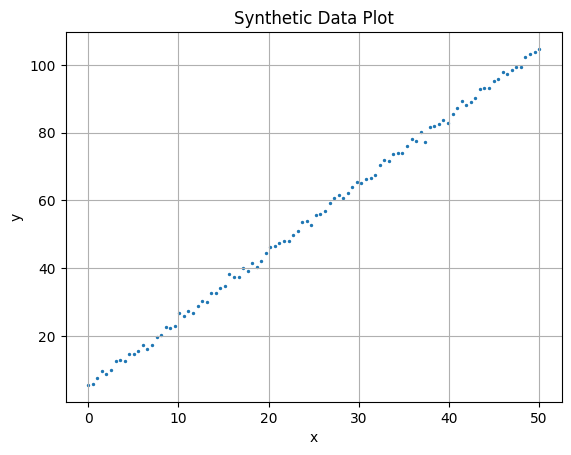

In [17]:
import matplotlib.pyplot as plt
plt.scatter(X, y, s=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data Plot')
plt.grid()
plt.show()

### 2. Prepare the Data

To include the bias term in our weight vector, add a column of 1s to your feature matrix X. This allows us to represent both the bias and feature weight in a single vector, simplifying our implementation.


In [18]:
intercept = np.ones(X.shape[0])
x_with_intercept = np.column_stack((intercept, X)) 
x_with_intercept

array([[ 1.        ,  0.        ],
       [ 1.        ,  0.50505051],
       [ 1.        ,  1.01010101],
       [ 1.        ,  1.51515152],
       [ 1.        ,  2.02020202],
       [ 1.        ,  2.52525253],
       [ 1.        ,  3.03030303],
       [ 1.        ,  3.53535354],
       [ 1.        ,  4.04040404],
       [ 1.        ,  4.54545455],
       [ 1.        ,  5.05050505],
       [ 1.        ,  5.55555556],
       [ 1.        ,  6.06060606],
       [ 1.        ,  6.56565657],
       [ 1.        ,  7.07070707],
       [ 1.        ,  7.57575758],
       [ 1.        ,  8.08080808],
       [ 1.        ,  8.58585859],
       [ 1.        ,  9.09090909],
       [ 1.        ,  9.5959596 ],
       [ 1.        , 10.1010101 ],
       [ 1.        , 10.60606061],
       [ 1.        , 11.11111111],
       [ 1.        , 11.61616162],
       [ 1.        , 12.12121212],
       [ 1.        , 12.62626263],
       [ 1.        , 13.13131313],
       [ 1.        , 13.63636364],
       [ 1.        ,

### 3. Initialize Parameters

Initialize your weight vector with zeros. Since we have one feature plus the bias term, your weight vector should have shape (2,), where the first element represents the bias and the second represents the feature weight.

In [19]:
weight_vector = np.zeros(2)
weight_vector.shape

(2,)

### 4. Implement Gradient Descent
Compute the gradient (formula is provided in the introduction) and update weights.


In [20]:
MAX_ITERATION = 10000
LEARNING_RATE = 1e-3

def loss_gradient(weight_vector, X_with_intercept, y):
    product = np.dot(X_with_intercept, weight_vector) - y
    return (2.0/y.shape[0])*np.dot(X_with_intercept.T ,product)

def loss_function(weight_vector, X_with_intercept, y):
    product = np.dot(X_with_intercept, weight_vector) - y
    return np.mean(product**2)

def gradient_descent(learning_rate, max_iteration, weight_vector, X_with_intercept, y):
    iteration = 0
    loss_function_values = [loss_function(weight_vector, X_with_intercept, y)]
    while iteration < max_iteration:
        weight_vector = weight_vector - learning_rate * loss_gradient(weight_vector, X_with_intercept, y)
        loss_function_values.append(loss_function(weight_vector, X_with_intercept, y))
        iteration += 1

    return weight_vector, loss_function_values

### 5. Run the Training Loop
Put it all together to train the model. Track values of the loss function during this process. 

In [21]:
outcome_weight_vector, loss_function_values  = gradient_descent(LEARNING_RATE, MAX_ITERATION, weight_vector, x_with_intercept, y)
# loss_function_values

### 6. Check Your Results
After training, compare your weights to the true ones. Plot the data and compare fitted model with the ground truth line.

In [22]:
print('Learnt weights (bias, slope):', outcome_weight_vector)
print('True weights (bias, slope):', original_weights)
print('Absolute error:', np.abs(outcome_weight_vector - original_weights))
print('Initial loss:', loss_function_values[0])
print('Final loss:', loss_function_values[-1])
print(f'Best loss in run: {min(loss_function_values)} at iteration {int(np.argmin(loss_function_values))}')

Learnt weights (bias, slope): [4.79732716 2.00365022]
True weights (bias, slope): [5. 2.]
Absolute error: [0.20267284 0.00365022]
Initial loss: 3866.9178594158752
Final loss: 0.8151309785471977
Best loss in run: 0.8151309785471977 at iteration 10000


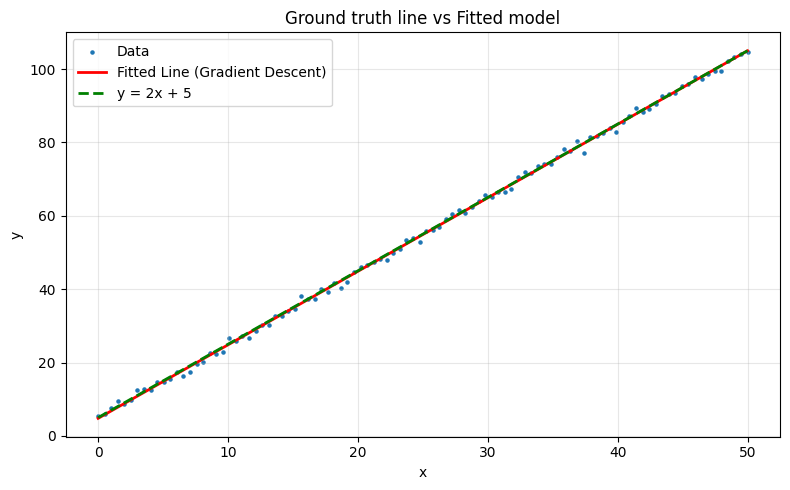

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(X.flatten(), y, s=5, label='Data')
plt.plot(X.flatten(), np.dot(x_with_intercept, outcome_weight_vector), 'r-', linewidth=2, label='Fitted Line (Gradient Descent)')
plt.plot(X.flatten(), np.dot(x_with_intercept, original_weights), 'g--', linewidth=2, label='y = 2x + 5')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ground truth line vs Fitted model')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7. Experiment with Learning Rate
The learning rate α controls how big of a step we take during each iteration of gradient descent. Try training your model with different learning rates: $\alpha \in [10^{-6}, 10^{-5}, 10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}]$. For each value:
- Plot the loss curve (loss vs. epoch)
- Record the final weights and final loss
- Observe how quickly (or slowly) the model converges

What happens when the learning rate is too small? Too large? Is there an optimal value in this range?

In [24]:
LEARNING_RATES = [1e-6,1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
results = {}
for lr in LEARNING_RATES:
    new_weight_vector = np.zeros(2)
    iter_weight_vector, iter_loss_function_values  = gradient_descent(lr, MAX_ITERATION, new_weight_vector, x_with_intercept, y)
    results[lr] = {'weight_results': iter_weight_vector, 'loss_results': iter_loss_function_values}
    

/var/folders/7z/120jpgfd64x1z9mv4s95z_f80000gn/T/ipykernel_61972/2952929685.py:10: RuntimeWarning: overflow encountered in square
  return np.mean(product**2)


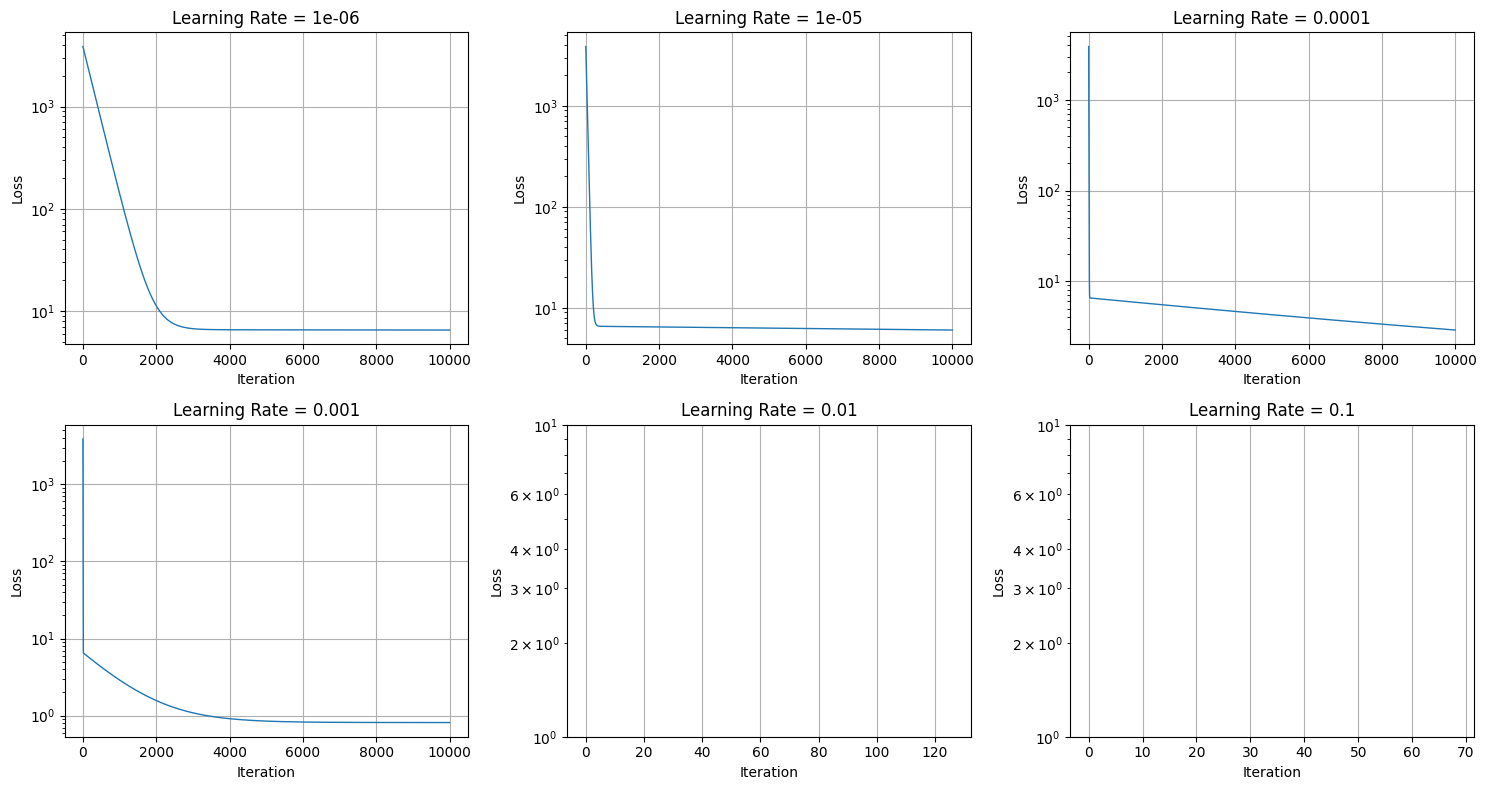

Summary of Results:

Learning Rate   Final Bias      Final Slope     Final Loss     
------------------------------------------------------------
1e-06           0.0881          2.1443          6.5142         
1e-05           0.2996          2.1379          6.0170         
0.0001          1.9586          2.0884          2.9031         
0.001           4.7973          2.0037          0.8151         
0.01            nan             nan             nan            
0.1             nan             nan             nan            


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, lr in enumerate(LEARNING_RATES):
    axes[idx].plot(results[lr]['loss_results'], linewidth=1)
    axes[idx].set_title(f'Learning Rate = {lr}')
    axes[idx].set_xlabel('Iteration')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid()
    axes[idx].set_yscale('log')

plt.tight_layout()
plt.show()

print("Summary of Results:\n")
print(f"{'Learning Rate':<15} {'Final Bias':<15} {'Final Slope':<15} {'Final Loss':<15}")
print("-" * 60)
for lr in LEARNING_RATES:
    bias = results[lr]['weight_results'][0]
    slope = results[lr]['weight_results'][1]
    loss = results[lr]['loss_results'][-1]
    print(f"{lr:<15} {bias:<15.4f} {slope:<15.4f} {loss:<15.4f}")

### Coclusions
The pattern observed:

Learning rate 1e-6, 1e-5: Too small, **converges slowly**, poor final weights especialt bias. 

Learning rate 1e-4: Better, **decent convergence**, better value of final bias. 

Learning rate 1e-3: This one is **optimal** learning rate, **excellent convergence**, the coefficient here are great and bias is the nearest to original bias. 

Learning rate 1e-2, 1e-1: Too large learning rates, causing **divergence** and NaN outcome - we obtain too large weight updates causing huge predictions. RuntimeWarning present in outcome of the training in this task confirms this: when computing product**2, the values get so large they overflow and produce NaN.




### 8. Explore Training Duration
Set `num_epochs` to larger values like 100 or 1000 and observe the training process:
- Does the loss continue to decrease throughout training, or does it plateau?
- At what point does the model effectively converge?
- Plot the loss curve for the extended training and identify where diminishing returns begin
- Calculate how close your final weights are to the true weights after different numbers of epochs

This exercise helps you understand when to stop training to avoid wasting computational resources.

In [26]:
epochs = [100, 500, 1000, 5000, 10000, 20000]
epoch_results = {}
for epoch in epochs:
    new_weight_vector = np.zeros(2)
    iter_weight_vector, iter_loss_function_values  = gradient_descent(LEARNING_RATE, epoch, new_weight_vector, x_with_intercept, y)
    epoch_results[epoch] = {'weight_results': iter_weight_vector, 'loss_results': iter_loss_function_values}


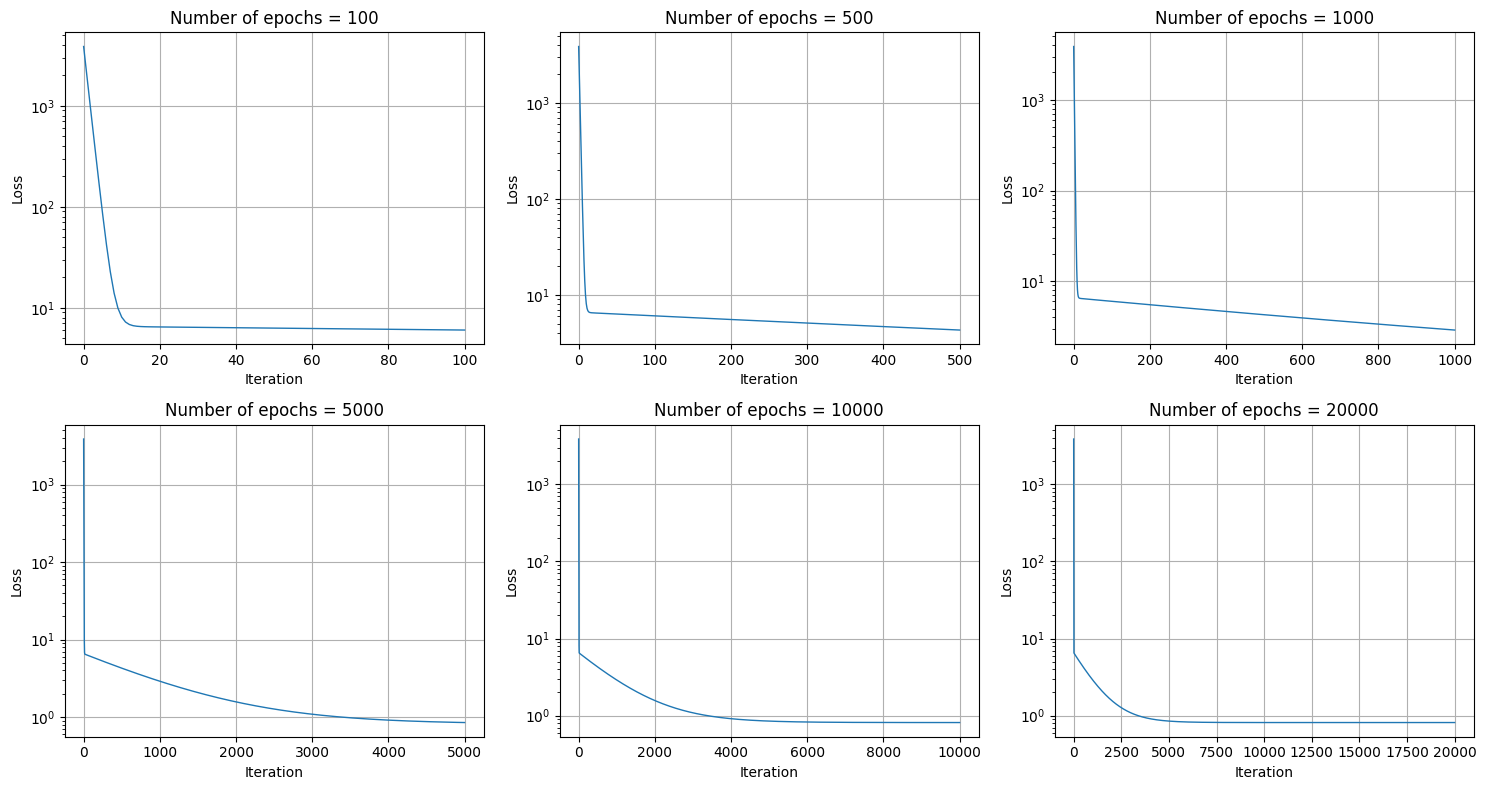

Summary of Results:

Nmbr of epochs  Final Bias      Final Slope     Abs Weights                 Final Loss     
----------------------------------------------------------------------------------------------------
100             0.2996          2.1379          [4.70038594 0.13794422]     6.0169         
500             1.1310          2.1131          [3.86899454 0.1131203 ]     4.2818         
1000            1.9590          2.0884          [3.04103716 0.08839891]     2.9026         
5000            4.4501          2.0140          [0.54994323 0.01401912]     0.8510         
10000           4.7973          2.0037          [0.20267284 0.00365022]     0.8151         
20000           4.8270          2.0028          [0.17300005 0.00276424]     0.8149         


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, epoch in enumerate(epochs):
    axes[idx].plot(epoch_results[epoch]['loss_results'], linewidth=1)
    axes[idx].set_title(f'Number of epochs = {epoch}')
    axes[idx].set_xlabel('Iteration')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid()
    axes[idx].set_yscale('log')

plt.tight_layout()
plt.show()

print("Summary of Results:\n")
print(f"{'Nmbr of epochs':<15} {'Final Bias':<15} {'Final Slope':<15} {'Abs Weights':<28}{'Final Loss':<15}")
print("-" * 100)
for epoch in epochs:
    bias = epoch_results[epoch]['weight_results'][0]
    slope = epoch_results[epoch]['weight_results'][1]
    abs_weight_vectors = np.abs(epoch_results[epoch]['weight_results'] - original_weights)
    loss = epoch_results[epoch]['loss_results'][-1]
    print(f"{epoch:<15} {bias:<15.4f} {slope:<15.4f} {abs_weight_vectors}     {loss:<15.4f}")

## Conclusions
- Does the loss continue to decrease throughout training, or does it plateau?  

With larger number of epochs, the function begins to be plateau but this plateau effect is visible from 10 000 epochs.

- At what point does the model effectively converge?  

As we see in the table above there is huge loss drop between number of epochs up to 5 000. There are smaller changes after 5 000 epochs. So the optimal number of epochs could be 10 000 for effective convergence as we can see that later, the Final Loss doesn't change that visibly.

- Plot the loss curve for the extended training and identify where diminishing returns begin.

After 10 000 epochs, additional training only improves loss by percentiles.  We can see it in the Final Loss column in the table above.

- Calculate how close your final weights are to the true weights after different numbers of epochs. 

The obtained abs differences in weights are present in the above table. At 10,000 epochs, the learned weights showed absolute errors for each of approximately [0.203, 0.004], or 4.06% for bias and 0.20% for slope. At 20,000 epochs, the improvement in weights is negligible. We've got absolute errors 3.46% for bias and 0.14% for slope. It confirms that 10,000 epochs is the optimal stopping point.


For this problem, training for approximately 10,000 epochs provides an optimal balance between model performance and computational efficiency.

### 9. Visualize the Loss Landscape
Create a visualization of the loss function across different weight values:
- Generate a grid of weight values
- Calculate the loss at each point in this grid
- Create a contour plot showing the "landscape" of the loss function
- Mark your initial weights, final weights, and the true weights on this plot

This visualization will help you understand the shape of the objective function you're optimizing and how gradient descent navigates this landscape to find the minimum.

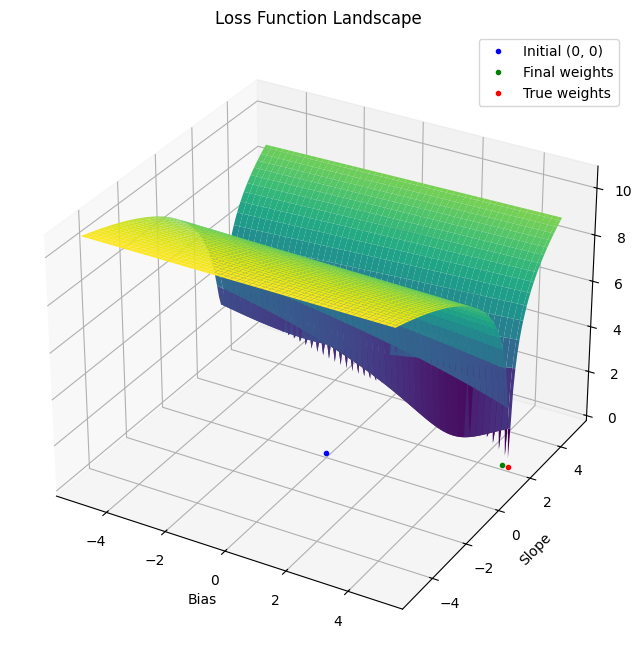

In [28]:
from matplotlib import cm
bias_range = np.linspace(-5, 5, 100)
slope_range = np.linspace(-5, 5, 100)
BIAS_GRID, SLOPE_GRID = np.meshgrid(bias_range, slope_range)  # tworzymy wszystkie polaczenia

J = np.zeros(BIAS_GRID.shape)
for i in range(BIAS_GRID.shape[0]):
    for j in range(BIAS_GRID.shape[1]):
        curr_weights = np.array([BIAS_GRID[i, j], SLOPE_GRID[i, j]])
        J[i, j] = loss_function(curr_weights, x_with_intercept, y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(BIAS_GRID, SLOPE_GRID, np.log(J), cmap=cm.viridis)
ax.plot(0, 0, 'bo', markersize=3, label='Initial (0, 0)')
ax.plot(outcome_weight_vector[0], outcome_weight_vector[1], 'go', markersize=3, label='Final weights')
ax.plot(original_weights[0], original_weights[1], 'ro', markersize=3, label='True weights')
ax.set_xlabel('Bias')
ax.set_ylabel('Slope')
ax.set_title('Loss Function Landscape')
ax.legend()



### 10. Analytical Solution
For linear regression, the closed-form solution is 

$$\widehat{\mathbf{w}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Compare the parameters and final MSE you get via gradient descent with those from the analytical solution. Are they similar?


In [29]:
analitical_weights = np.dot(np.linalg.inv(np.dot(x_with_intercept.T, x_with_intercept)), np.dot(x_with_intercept.T, y))
analytical_last_loss = loss_function(analitical_weights, x_with_intercept, y)

gradient_descent_weights, gradient_descent_loss_function = gradient_descent(LEARNING_RATE, MAX_ITERATION, weight_vector, x_with_intercept, y)

In [30]:
print(f'{"Solution type":<20}{"Final MSE":<15} {"Weight Vector":<30}')
print("-" * 70)
print(f'{"Gradient Descent":<20}{gradient_descent_loss_function[-1]:<15.4f} {gradient_descent_weights}')
print(f'{"Analytical":<20}{analytical_last_loss:<15.4f} {analitical_weights}')


print(f"\nWeight Differences:")
print(f"{np.abs(analitical_weights - gradient_descent_weights)}")

print(f"Loss Difference:")
print(f"{np.abs(loss_function_values[-1] - analytical_last_loss):.4f}")


Solution type       Final MSE       Weight Vector                 
----------------------------------------------------------------------
Gradient Descent    0.8151          [4.79732716 2.00365022]
Analytical          0.8149          [4.82718715 2.00275865]

Weight Differences:
[0.02985998 0.00089157]
Loss Difference:
0.0002


## Conclusion
Both methods return almost identical weight vectors, the differences in slope and bias are presented above. The MSE is also practically the same. This means that the gradient descend with chosen learning rate $1e-3$ and number of epochs 10 000 reaches optimal point of analytical solution.